In [363]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import normalize

In [403]:
titanic = fetch_openml(data_id=40945)
catagories = ["pclass","sex", "age", "sibsp", "parch", "fare"]
data = titanic.data[categories]
target = titanic.target
tmp = data["sex"]
data["sex"] = tmp.cat.rename_categories([0,1])

/var/folders/8y/lxd4m2nx5y750shcys1g9dqm0013cl/T/ipykernel_13010/3068836886.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["sex"] = tmp.cat.rename_categories([0,1])


In [404]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")

In [405]:
tmp = pd.notna(data)

In [406]:
dropped_rows = []
for i in range(len(tmp)):
    for entry in tmp.iloc[i]:
        if entry==False:
            dropped_rows.append(i)
            break

In [407]:
data = data.drop(dropped_rows)
target = target.drop(dropped_rows)
categories_training = ["age", "sibsp", "parch", "fare"]
data_training = data[categories_training]

In [409]:
kmeans.fit(data_training)
cluster_centres = {}
for a,b in [(x,y) for x,y in zip(categories_training, kmeans.cluster_centers_.T)]:
    cluster_centres[a] = b
cluster_labels = kmeans.labels_
nclusters = np.max(cluster_labels)+1
clusterwidth = (nclusters-1)/nclusters
sorted_data=data
sorted_data["cluster"] = cluster_labels

In [410]:
name_dict = {
    "pclass" : "ticket class",
    "sex" : "sex",
    "age" : "age",
    "sibsp" : "# siblings and/or spouses aboard",
    "parch" : "# parents and/or children aboard",
    "fare" : "passenger fare"
}

binning_dict = {
    "pclass" : 3,
    "sex" : 2,
    "age" : 10,
    "sibsp" : 9,
    "parch" : 7,
    "fare" : 5
}

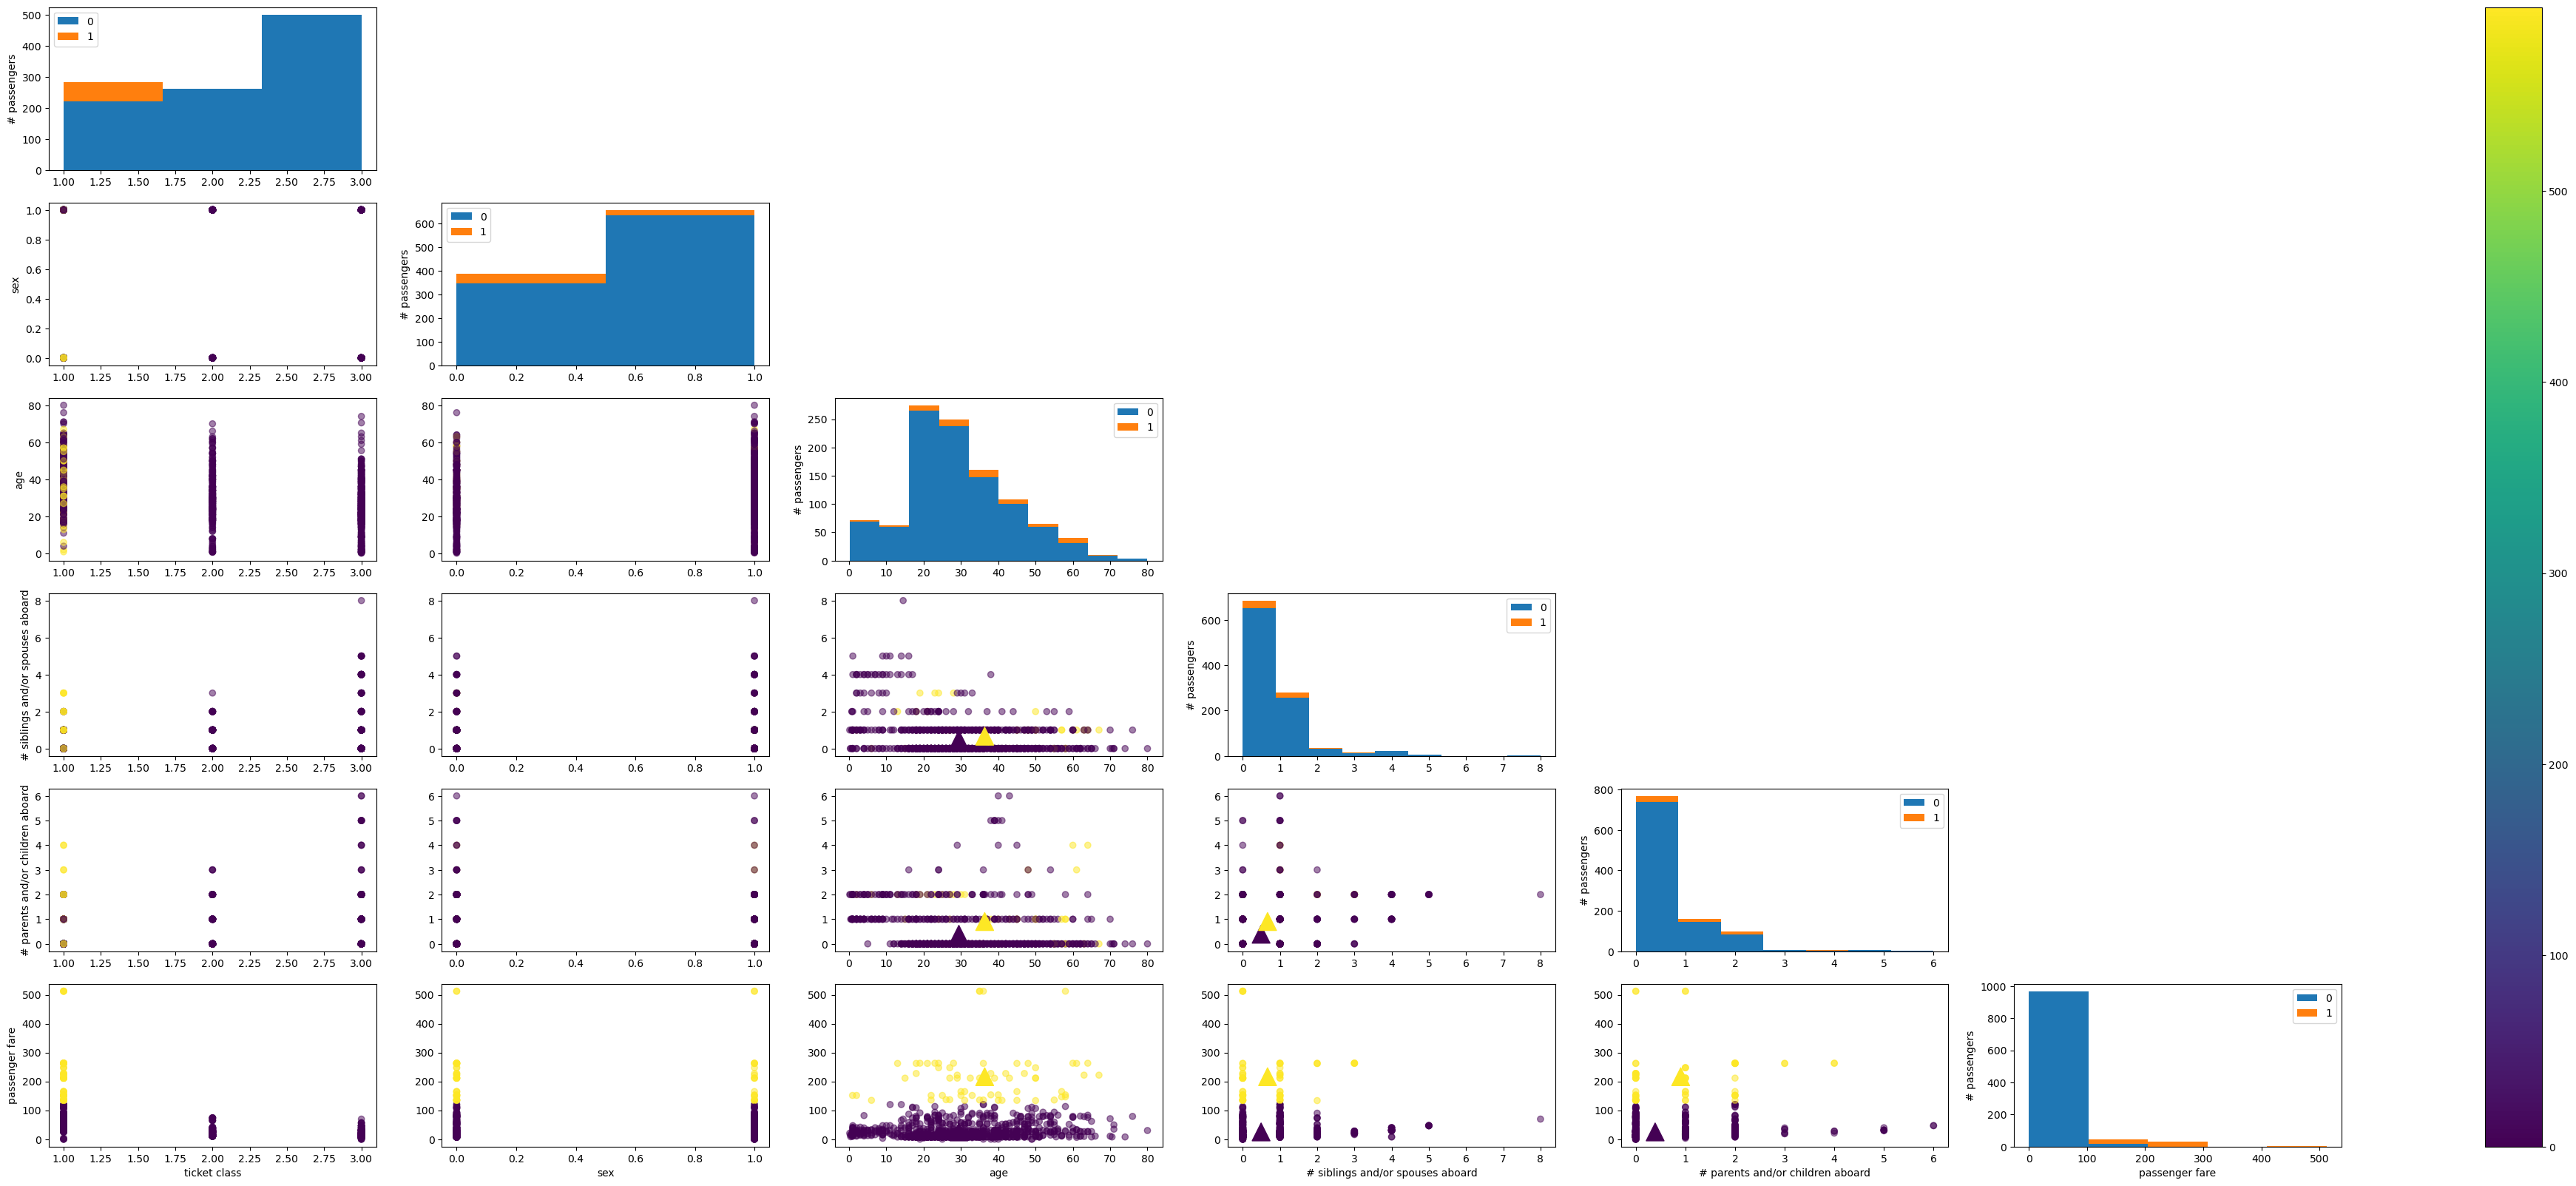

In [435]:
fig, axs = plt.subplots(
    len(categories), len(categories), figsize=(50,20))

axs = axs.T
for x in range(len(categories)):
    x_label = categories[x]
    axs[x,5].set_xlabel(name_dict[x_label])
    for y in range(len(categories)):
        if x<y:
            y_label = categories[y]
            axs[x,y].scatter(data[x_label][:], data[y_label][:], c=cluster_labels, alpha=0.5)
            if x_label in data_training and y_label in data_training:
                axs[x,y].scatter(cluster_centres[x_label], cluster_centres[y_label], marker="^", s=300, c=np.arange(0, nclusters, 1))
            axs[0,y].set_ylabel(name_dict[y_label])
        elif x==y:
            nbins = binning_dict[x_label]
            plotData = [sorted_data.loc[(sorted_data["cluster"]==c)][x_label] for c in range(0, nclusters)]
            axs[x,y].hist(plotData, bins=nbins, stacked=True, label=range(0, nclusters))
            axs[x,y].set_ylabel("# passengers")
            axs[x,y].legend()
        else:
            axs[x,y].set_visible(False)

fig.colorbar(im, ax=axs)
plt.show()

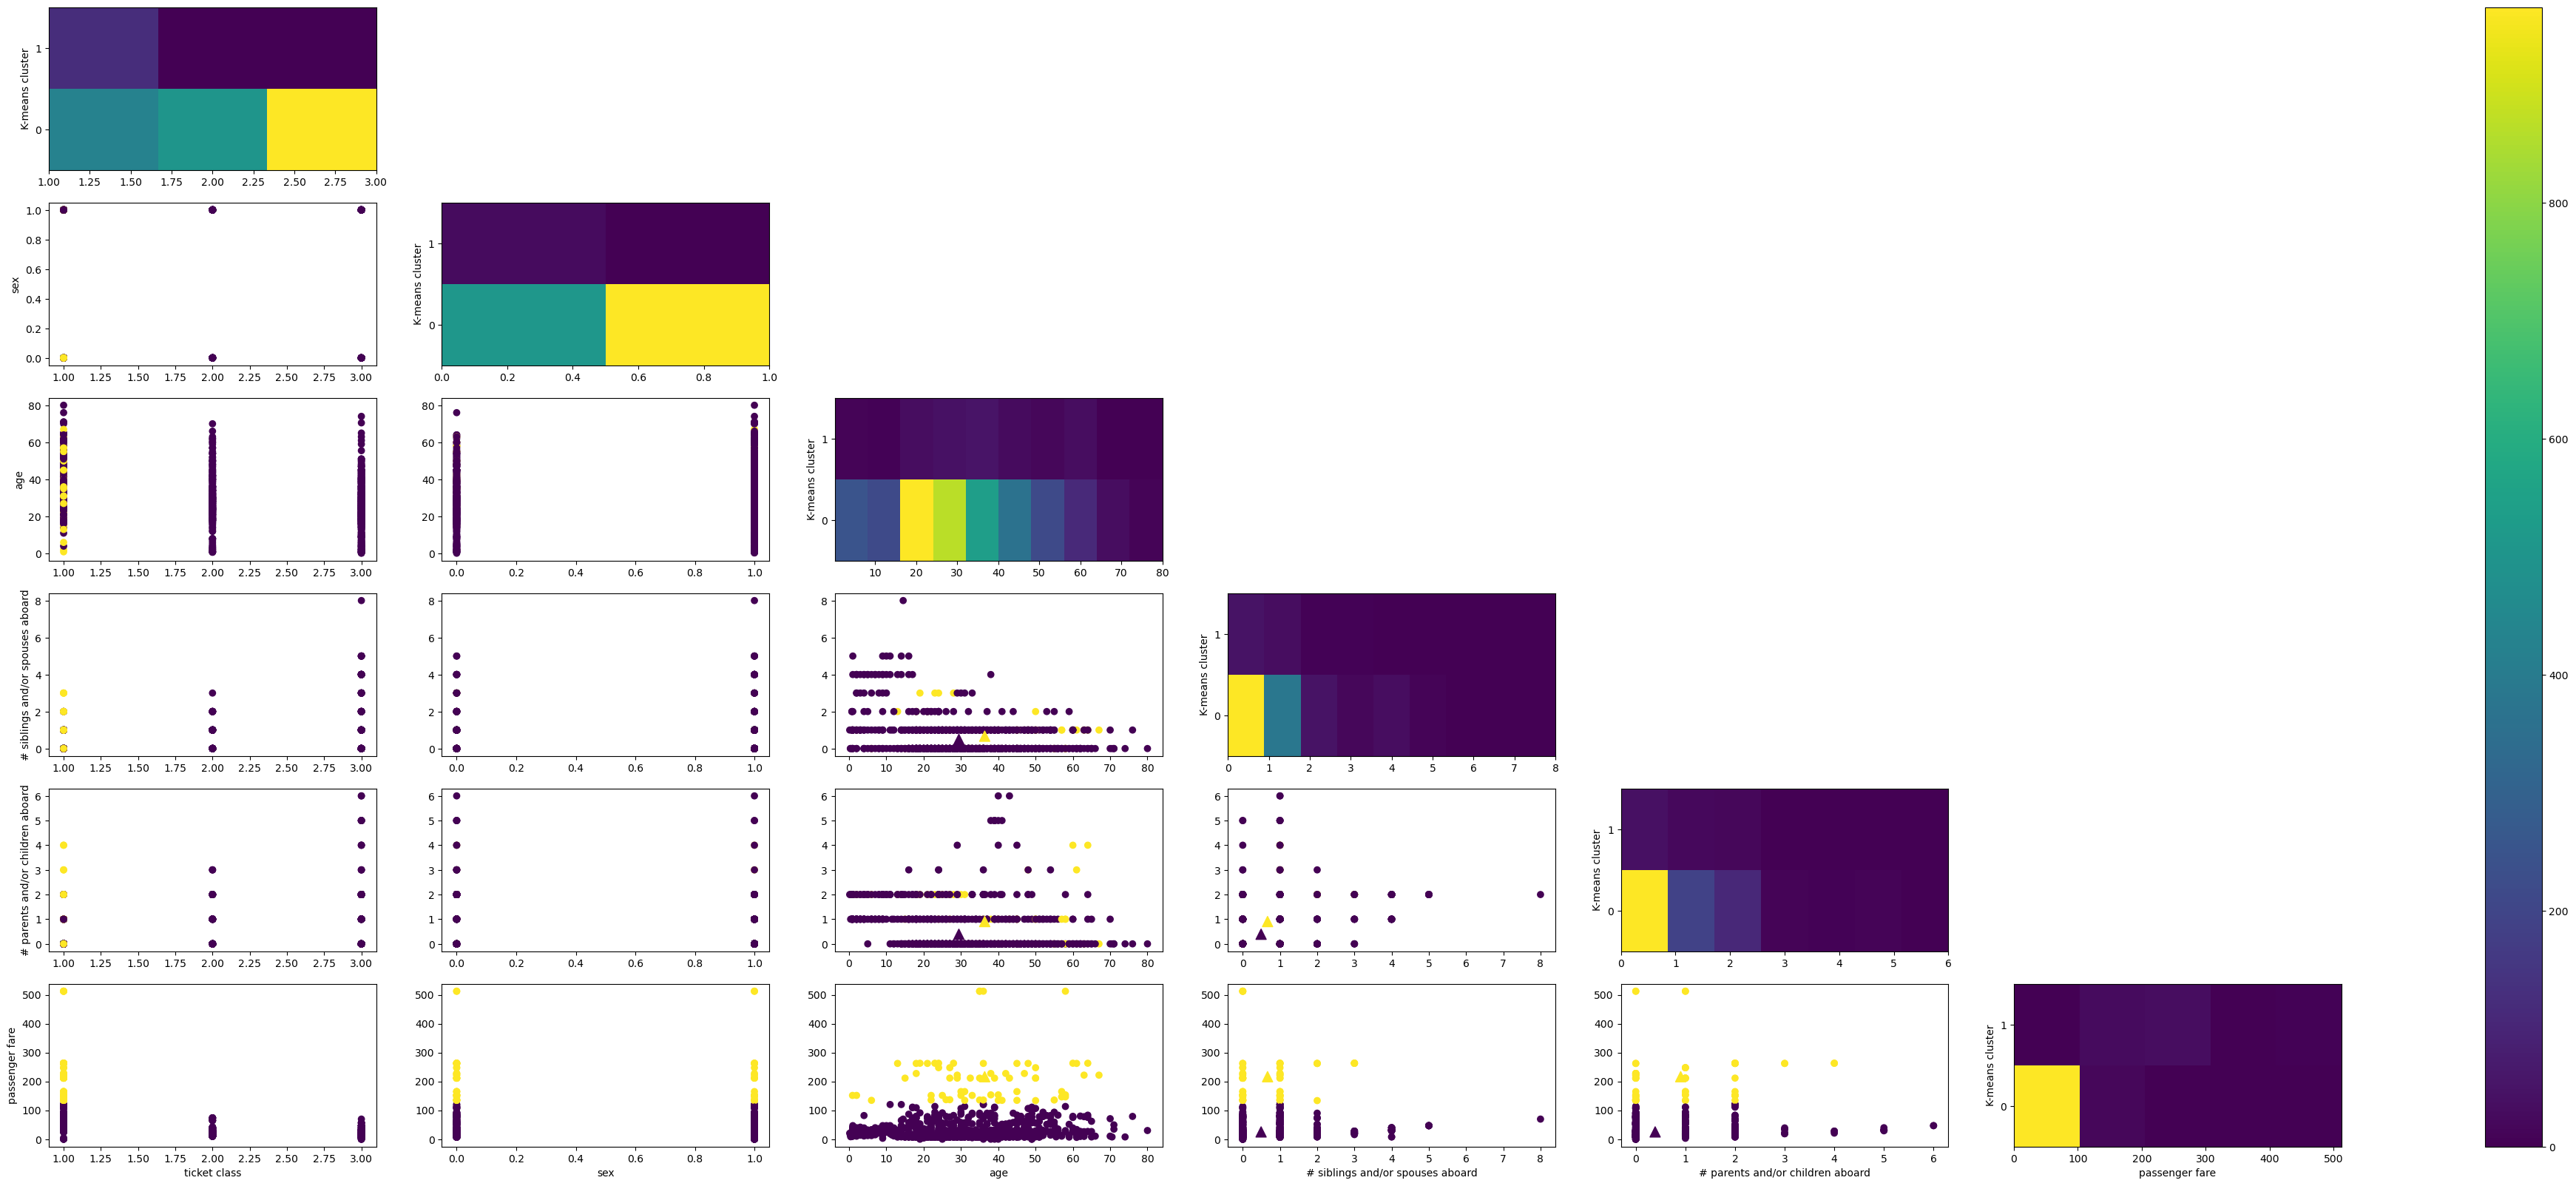

In [412]:
fig, axs = plt.subplots(
    len(categories), len(categories), figsize=(50,20))

axs = axs.T
for x in range(len(categories)):
    x_label = categories[x]
    axs[x,5].set_xlabel(name_dict[x_label])
    for y in range(len(categories)):
        if x<y:
            y_label = categories[y]
            axs[x,y].scatter(data[x_label][:], data[y_label][:], c=cluster_labels)
            if x_label in data_training and y_label in data_training:
                axs[x,y].scatter(cluster_centres[x_label], cluster_centres[y_label], marker="^", s=100, c=np.arange(0, nclusters, 1))
            axs[0,y].set_ylabel(name_dict[y_label])
        elif x==y:
            nbins = (binning_dict[x_label], nclusters)
            counts, xedges, yedges, im = axs[x,y].hist2d(data[x_label][:], cluster_labels, bins=nbins)
            axs[x,y].set_ylabel("K-means cluster")
            yticks = np.arange(clusterwidth/2, nclusters-1+clusterwidth/2, clusterwidth)
            ylabels = np.arange(0, nclusters, 1)
            if x_label in data_training and y_label in data_training:
                axs[x,y].scatter(cluster_centres[x_label], cluster_centres[y_label], marker="^", s=100, c=np.arange(0, nclusters, 1))
            axs[x,y].set_yticks(yticks, ylabels)
        else:
            axs[x,y].set_visible(False)

fig.colorbar(im, ax=axs)
plt.show()

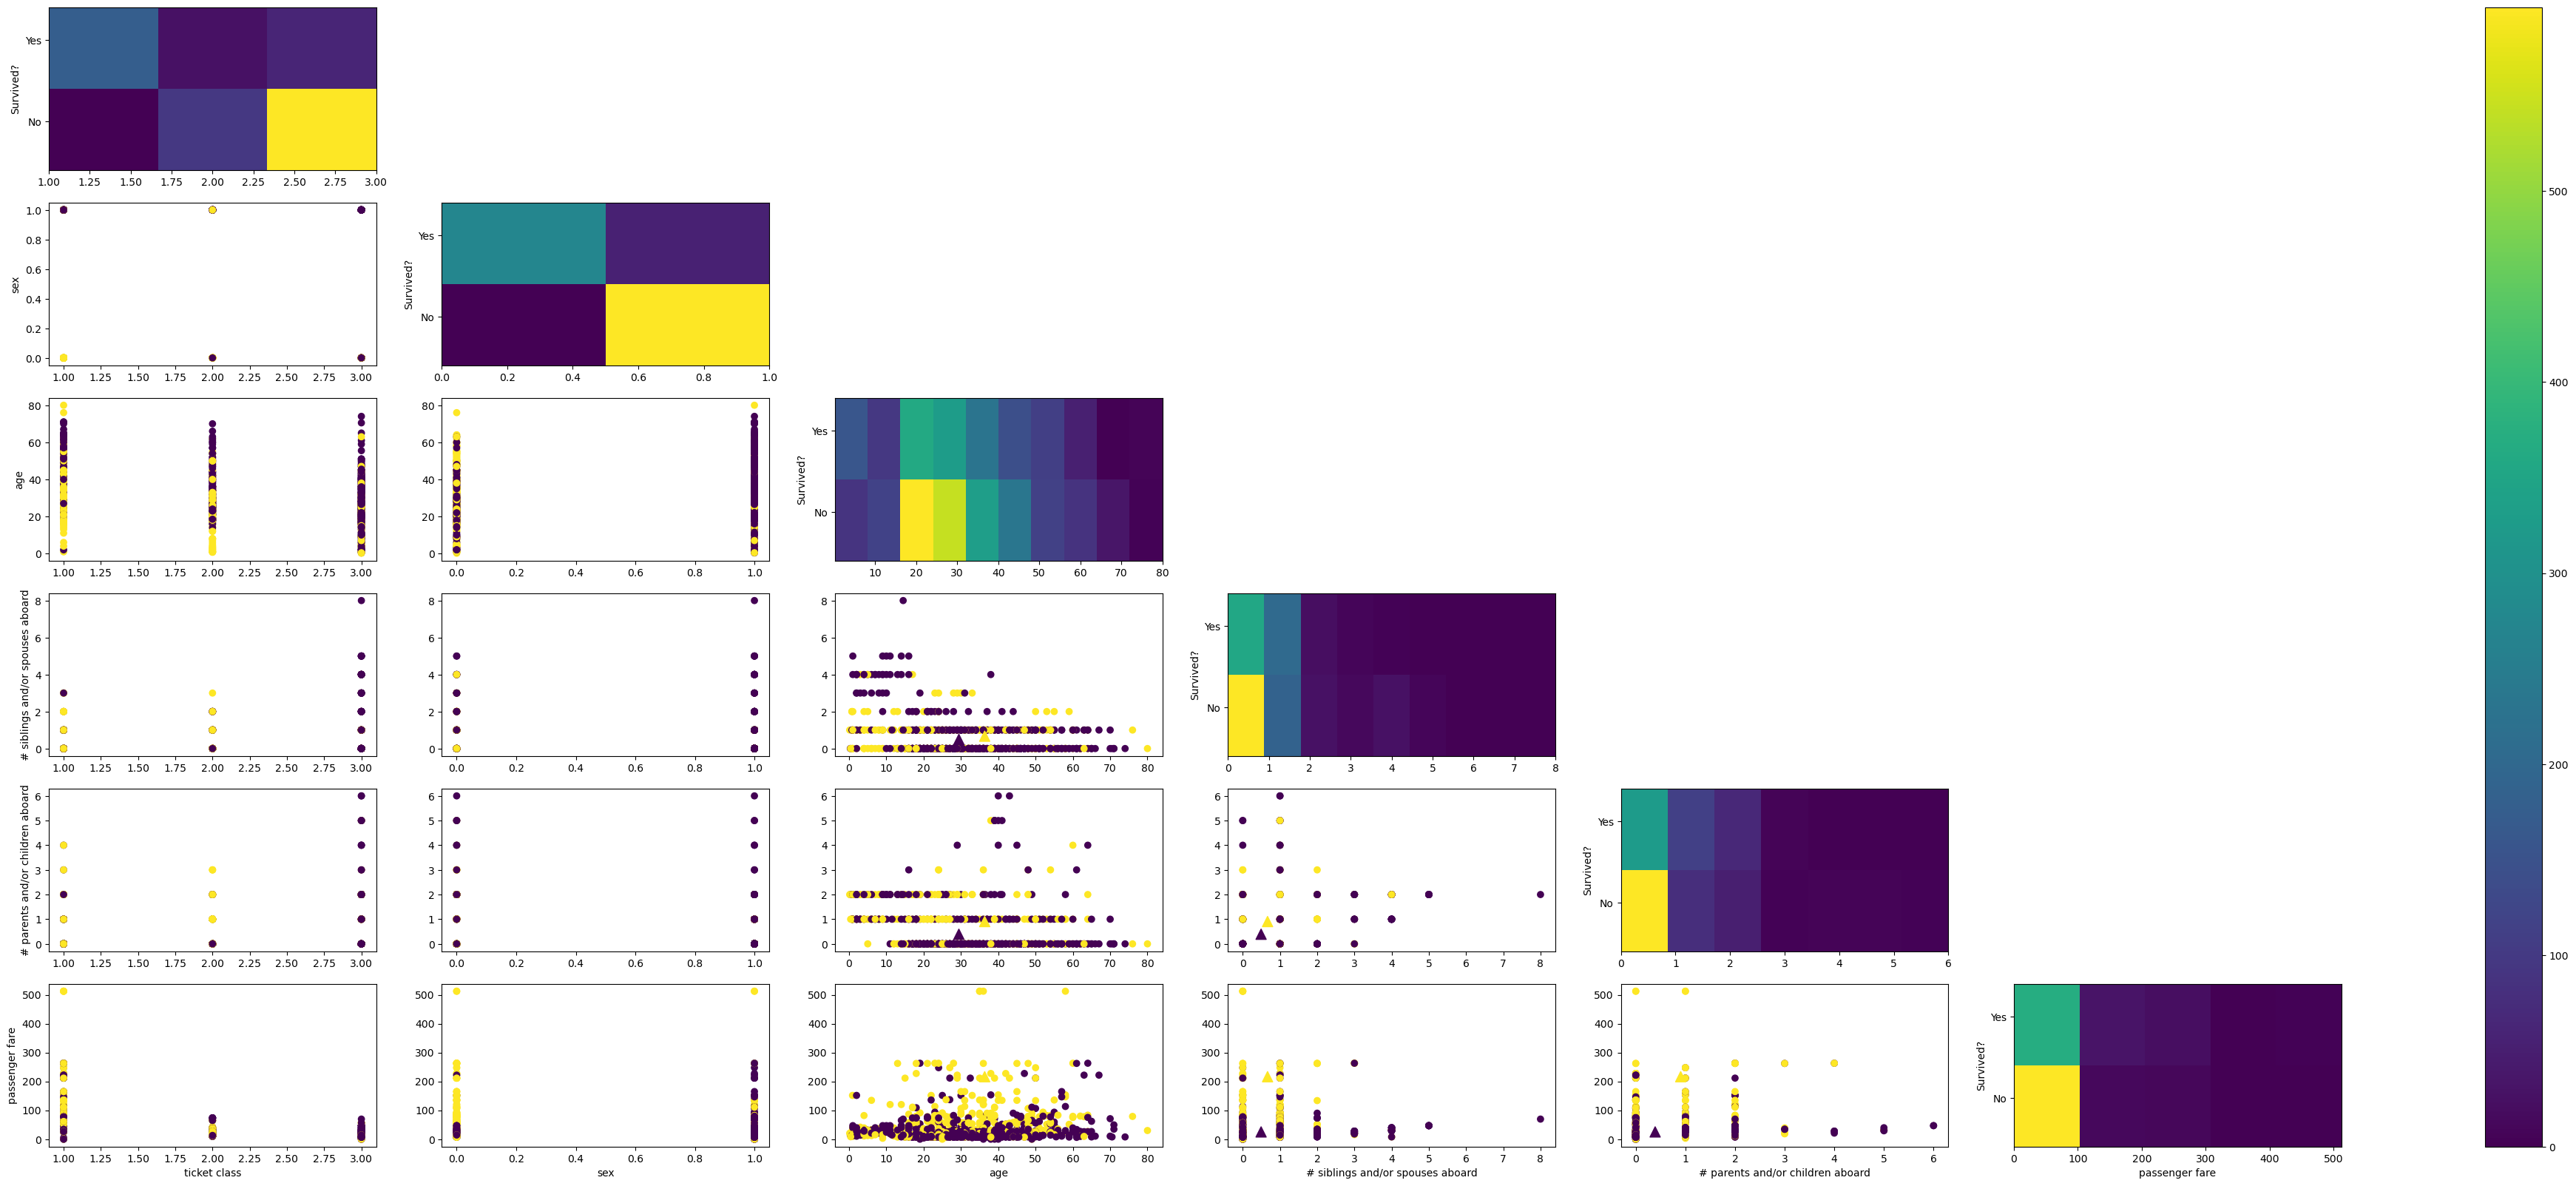

In [413]:
fig, axs = plt.subplots(
    len(categories), len(categories), figsize=(50,20))

axs = axs.T
for x in range(len(categories)):
    x_label = categories[x]
    axs[x,5].set_xlabel(name_dict[x_label])
    for y in range(len(categories)):
        y_label = categories[y]
        if x<y:
            axs[x,y].scatter(data[x_label][:], data[y_label][:], c=np.asarray(target.values[:], dtype="int32"))
            if x_label in data_training and y_label in data_training:
                axs[x,y].scatter(cluster_centres[x_label], cluster_centres[y_label], marker="^", s=100, c=np.arange(0, nclusters, 1))
            axs[0,y].set_ylabel(name_dict[y_label])
        elif y==x:
            nbins = (binning_dict[x_label], 2)
            counts, xedges, yedges, im = axs[x,y].hist2d(data[x_label][:], np.asarray(target.values[:],dtype="int32"), bins=nbins)
            axs[x,y].set_ylabel("Survived?")
            xticks = [0.3, 0.8]
            xlabels = ["No", "Yes"]
            axs[x,y].set_yticks(xticks, xlabels)
        else:
            axs[x,y].set_visible(False)
        
fig.colorbar(im, ax=axs)
plt.show()

In [414]:
#Things to try:
#1. Run a clustering on the less discrete subset of data - age, #siblings, #parents, #passenger fare
#2. See if this demonstrates any keen insights in and of itself
#3. Compare the mortality of these clusters to identify if we have two groups?

In [426]:
[sorted_data.loc[(sorted_data["cluster"]==c)][x_label] for c in range(0, nclusters)]

[5       26.5500
 6       77.9583
 7        0.0000
 8       51.4792
 9       49.5042
          ...   
 1301     7.2250
 1304    14.4542
 1306     7.2250
 1307     7.2250
 1308     7.8750
 Name: fare, Length: 982, dtype: float64,
 0      211.3375
 1      151.5500
 2      151.5500
 3      151.5500
 4      151.5500
          ...   
 312    211.5000
 313    211.5000
 314    211.5000
 319    134.5000
 322    135.6333
 Name: fare, Length: 63, dtype: float64]